# Vision-Language Models for Lost & Found Retrieval

This notebook uses the pretrained CLIP vision-language model to search a collection of Lost & Found photographs with a natural-language query. For example, a query such as **“pink water bottle”** returns the three images that CLIP considers most similar.

The dataset comes from [Lost & Found Items on Roboflow Universe](https://universe.roboflow.com/mangoesclassifierdetector/lost-found-items). The training and validation images are combined into one searchable gallery. The test folder is intentionally excluded.

## Learning Objectives

1. Load a pretrained vision-language model with PyTorch and Hugging Face Transformers.
2. Convert images and text into normalized CLIP embeddings.
3. Rank images using cosine similarity and display the top three matches.

CLIP is **not trained or fine-tuned in this notebook**. “Using all the data” means computing and storing embeddings for every training and validation image so all of them can be searched.

## 1. Environment Setup

The notebook automatically uses CUDA when a CUDA-enabled PyTorch installation is available. CPU execution is also sufficient for this small dataset.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import torch
from transformers import CLIPModel, CLIPProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

c:\Users\abhig\Assignment 3\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
PyTorch version: 2.14.0+cpu


## 2. Load Pretrained CLIP

CLIP has an image encoder and a text encoder whose outputs share the same vector space. Related images and descriptions should have embeddings that point in similar directions. We use `openai/clip-vit-base-patch32` for pretrained inference.

In [2]:
MODEL_NAME = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"Loaded {MODEL_NAME}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 42745.32it/s]

Loaded openai/clip-vit-base-patch32


## 3. Load Training and Validation Images

The code finds COCO `_annotations.coco.json` files under `data/items/`. It includes the main training data and the `valid` folder, but skips any annotation file inside `test`. COCO category names are used only to create readable display labels; the image retrieval itself uses the photograph pixels.

In [3]:
DATA_DIR = Path("data/items")
ANNOTATION_FILENAME = "_annotations.coco.json"
IGNORED_LABELS = {"Person", "Daily-Necessities-Objects"}

images = []
image_paths = []
item_names = []
item_splits = []

annotation_files = [
    path for path in DATA_DIR.rglob(ANNOTATION_FILENAME)
    if "test" not in {part.lower() for part in path.relative_to(DATA_DIR).parts}
] if DATA_DIR.exists() else []

for annotation_file in sorted(annotation_files):
    split_name = "train" if annotation_file.parent == DATA_DIR else annotation_file.parent.name

    try:
        coco = json.loads(annotation_file.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as error:
        warnings.warn(f"Skipping {annotation_file}: {error}")
        continue

    category_names = {
        category["id"]: category["name"]
        for category in coco.get("categories", [])
    }
    labels_by_image = {}
    for annotation in coco.get("annotations", []):
        label = category_names.get(annotation.get("category_id"))
        if label and label not in IGNORED_LABELS:
            labels_by_image.setdefault(annotation["image_id"], set()).add(label)

    loaded_from_split = 0
    for image_info in coco.get("images", []):
        image_path = annotation_file.parent / image_info["file_name"]
        if not image_path.exists():
            warnings.warn(f"Missing image referenced by COCO JSON: {image_path}")
            continue

        try:
            with Image.open(image_path) as opened_image:
                image = opened_image.convert("RGB").copy()
        except (UnidentifiedImageError, OSError) as error:
            warnings.warn(f"Skipping unreadable image {image_path.name}: {error}")
            continue

        labels = sorted(labels_by_image.get(image_info["id"], {"Item"}))
        images.append(image)
        image_paths.append(image_path)
        item_names.append(" / ".join(labels))
        item_splits.append(split_name)
        loaded_from_split += 1

    print(f"Loaded {loaded_from_split} image(s) from {split_name}.")

if not images:
    raise FileNotFoundError(
        "No training or validation images were loaded. Extract the COCO dataset under data/items/."
    )

print(f"Search gallery size: {len(images)} images")
print(f"Included splits: {', '.join(sorted(set(item_splits)))}")
print("The test folder was excluded.")

Loaded 39 image(s) from train.
Loaded 11 image(s) from valid.
Search gallery size: 50 images
Included splits: train, valid
The test folder was excluded.


## 4. Create Image and Text Embeddings

Every gallery image is encoded once. Each image embedding is normalized to length 1. The query is encoded and normalized the same way. Because the vectors are normalized, their dot product is cosine similarity:

$$\operatorname{cosine\_similarity}(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert_2\lVert\mathbf{b}\rVert_2}$$

In [4]:
def encode_images(image_list, batch_size=16):
    embedding_batches = []

    with torch.inference_mode():
        for start in range(0, len(image_list), batch_size):
            batch = image_list[start:start + batch_size]
            pixel_values = processor(images=batch, return_tensors="pt")["pixel_values"].to(device)
            features = model.get_image_features(pixel_values=pixel_values)

            # Support both older and newer Transformers return formats.
            if not isinstance(features, torch.Tensor):
                features = features.pooler_output

            features = features / features.norm(dim=1, keepdim=True).clamp_min(1e-12)
            embedding_batches.append(features)

    return torch.cat(embedding_batches)

def encode_text(query):
    text_inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    text_inputs = {name: value.to(device) for name, value in text_inputs.items()}

    with torch.inference_mode():
        features = model.get_text_features(**text_inputs)
        if not isinstance(features, torch.Tensor):
            features = features.pooler_output
        features = features / features.norm(dim=1, keepdim=True).clamp_min(1e-12)

    return features

image_embeddings = encode_images(images)
print(f"Image embedding shape: {tuple(image_embeddings.shape)}")
print(f"First embedding norm: {image_embeddings[0].norm().item():.3f}")

Image embedding shape: (50, 512)
First embedding norm: 1.000


## 5. Search the Entire Gallery

The search function compares the query embedding with all 50 image embeddings, sorts the cosine-similarity scores from highest to lowest, and displays the top three.

In [5]:
def search_items(query, k=3):
    if not isinstance(query, str) or not query.strip():
        raise ValueError("Enter a non-empty text query.")

    query_embedding = encode_text(query.strip())
    similarities = (image_embeddings @ query_embedding.T).squeeze(1)
    match_count = min(k, len(images))
    top_indices = torch.argsort(similarities, descending=True)[:match_count]

    results = []
    for rank, index_tensor in enumerate(top_indices, start=1):
        index = index_tensor.item()
        results.append({
            "Rank": rank,
            "Item": item_names[index],
            "Split": item_splits[index],
            "Filename": image_paths[index].name,
            "Similarity": similarities[index].item(),
            "Image Index": index,
        })

    figure, axes = plt.subplots(1, match_count, figsize=(4.5 * match_count, 4.3))
    axes = np.atleast_1d(axes)
    for axis, result in zip(axes, results):
        axis.imshow(images[result["Image Index"]])
        axis.set_title(
            f"{result['Rank']}. {result['Item']}\nSimilarity: {result['Similarity']:.3f}",
            fontsize=11,
        )
        axis.axis("off")

    figure.suptitle(f'Query: "{query}"', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results).drop(columns="Image Index")

## 6. Enter a Query

Change only the text assigned to `query` and rerun this cell. The search always considers every training and validation image.

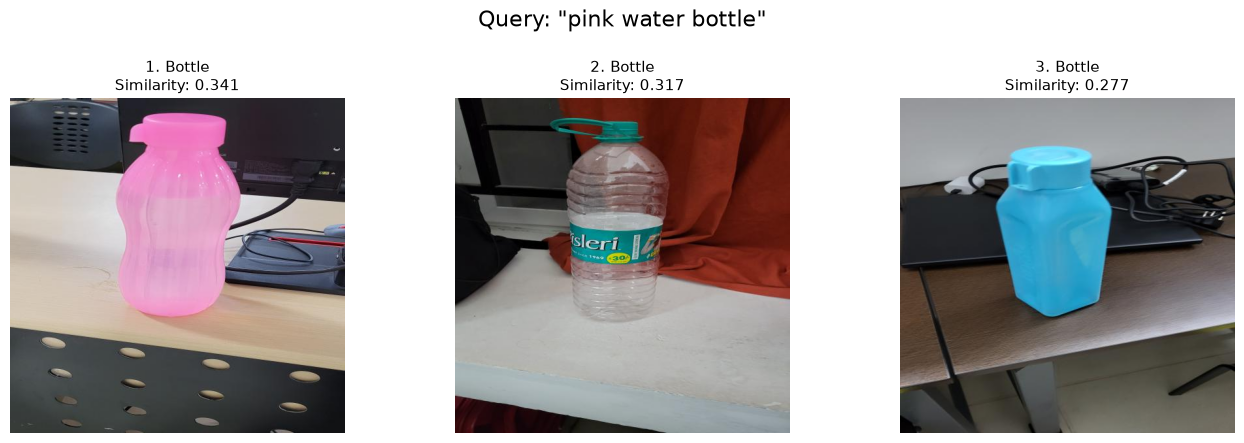

,Rank,Item,Split,Filename,Similarity
0,1,Bottle,valid,20240417_173441_jpg.rf.68decbefcc7fd02868eaf2d...,0.341436
1,2,Bottle,train,20240417_183849_jpg.rf.668af9995f8db2993cfd40f...,0.317416
2,3,Bottle,valid,20240417_183935_jpg.rf.7adba5496859c4e2769c652...,0.276989


In [ ]:
query = "pink water bottle"
top_matches = search_items(query, k=3)
top_matches

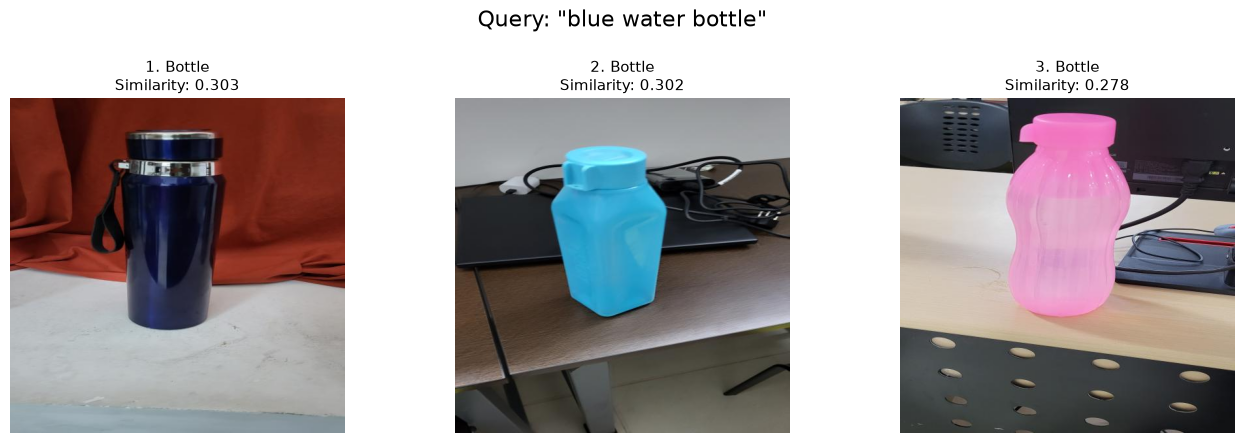

,Rank,Item,Split,Filename,Similarity
0,1,Bottle,train,20240417_183858_jpg.rf.8d8096316e89a3b5ab700ef...,0.302770
1,2,Bottle,valid,20240417_183935_jpg.rf.7adba5496859c4e2769c652...,0.301868
2,3,Bottle,valid,20240417_173441_jpg.rf.68decbefcc7fd02868eaf2d...,0.278369


In [7]:
query = "blue water bottle"
top_matches = search_items(query, k=3)
top_matches

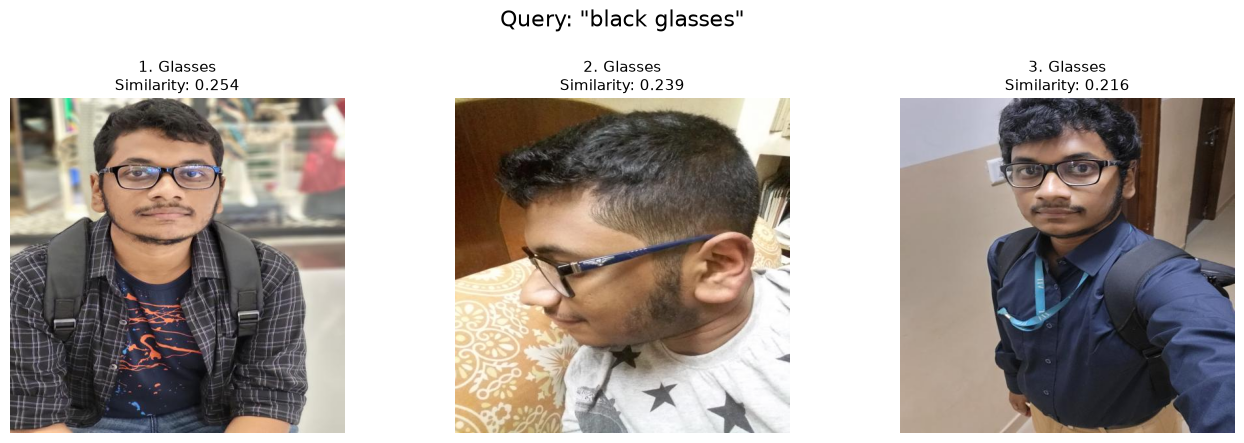

,Rank,Item,Split,Filename,Similarity
0,1,Glasses,train,20231220_183934_jpg.rf.27f1fd9562bd5f9b9439c6e...,0.253649
1,2,Glasses,train,20181031_212001_jpg.rf.87565a58c4edac7c8cdc6a9...,0.238852
2,3,Glasses,train,20240318_042416_jpg.rf.3991c8e9b07293567a10782...,0.215978


In [8]:
query = "black glasses"
top_matches = search_items(query, k=3)
top_matches

## What the Prototype Demonstrates

The query does not need to match a filename or COCO category exactly. CLIP compares the meaning of the text with the visual content of every photograph. This makes it useful for Lost & Found descriptions that include object type, color, appearance, or purpose.

A production Lost & Found system could compute an embedding when each found-item photo is uploaded, store that vector with the report, and compare a user's description against all stored vectors.

## Learning Resources

- [Hugging Face CLIP documentation](https://huggingface.co/docs/transformers/model_doc/clip) — model, processor, and embedding APIs.
- [OpenAI CLIP repository](https://github.com/openai/CLIP) — overview of CLIP and image-text similarity.

## GenAI Usage Statement — Review Before Submission

> Generative AI tools were used to help organize the notebook, explain the CLIP workflow, and assist with portions of the Python implementation. I reviewed and ran the code and used the exercise to understand image and text embeddings, normalization, cosine similarity, and semantic retrieval.
